# Analysis of the slice particles recorded by slice_analysis

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

import sys

sys.path.insert(0, "..")
import cfg_data
from utils import gaussian_mixture_fit

plt.style.use("dark_background")

In [2]:
fpath = Path("../Data/Particles")
fname = fpath / "M50L-06_particles.csv"
df = pd.read_csv(fname)
print(len(df))
print(df.head())

3603
   slice  grayvalue  area  mean_contrast  max_contrast   cx    cy
0    200        120     2       4.503635      4.878938  423   972
1    200        122     2       4.691287      5.254241  556  1118
2    200        119     2       4.128332      4.128332  495  1156
3    200        139     3       4.128332      4.128332  777  1187
4    200        135     2       4.315984      4.503635  772  1202


Text(0, 0.5, 'Cummulative Probability')

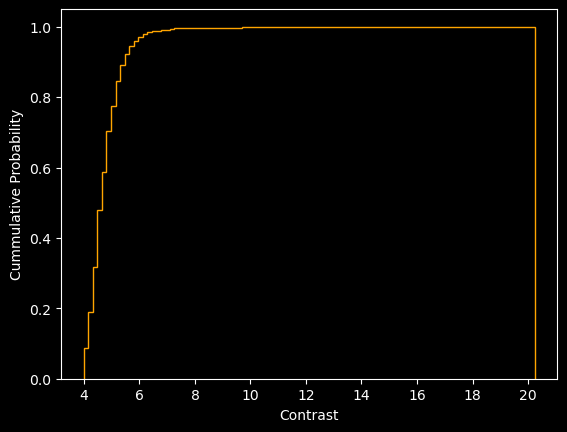

In [24]:
mean_contrast = df["mean_contrast"].to_numpy()
max_contrast = df["max_contrast"].to_numpy()
pos_x = df["cx"].to_numpy()
pos_y = df["cy"].to_numpy()
slice = df["slice"].to_numpy()
grayvalue = df["grayvalue"].to_numpy()

_ = plt.hist(
    max_contrast,
    bins=100,
    alpha=1.0,
    label="Mean Contrast",
    cumulative=True,
    density=True,
    histtype="step",
    color="orange",
)
plt.xlabel("Contrast")
plt.ylabel("Cummulative Probability")
# _ = plt.hist(mean_contrast, bins=100, alpha=0.75, label="Max Contrast")

In [25]:
amax = np.argmax(max_contrast)
print(f"Max contrast: {max_contrast[amax]} at ({pos_x[amax]}, {pos_y[amax]}) in slice {slice[amax]} with grayvalue {grayvalue[amax]}")

Max contrast: 20.24652 at (783, 1262) in slice 3732 with grayvalue 179


In [4]:
thresh = 4.7
np.count_nonzero(mean_contrast > thresh), np.count_nonzero(max_contrast > thresh)

(np.int64(1024), np.int64(1829))

/var/folders/29/803dzgr92dx7_lk8zb5y_j7r0000gn/T/ipykernel_35729/1321652401.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pos_x, pos_y, marker=".", cmap="plasma")


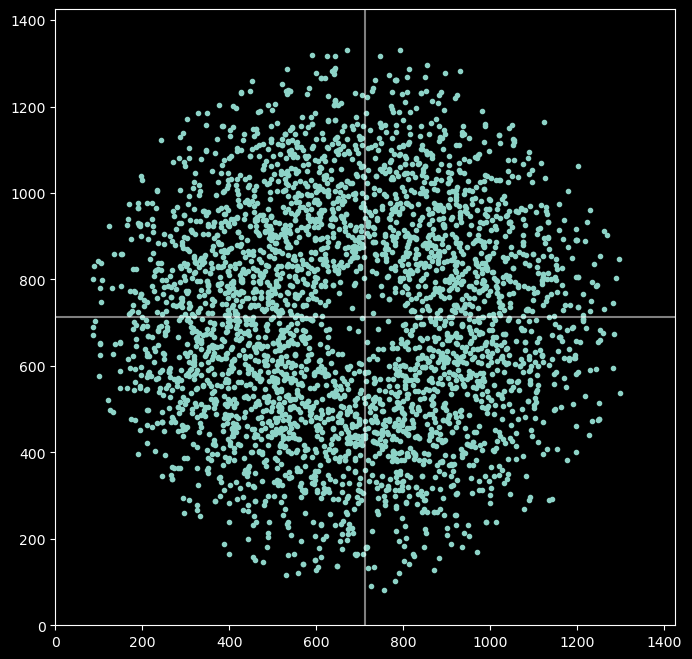

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(pos_x, pos_y, marker=".", cmap="plasma")
plt.xlim(0, 1425)
plt.ylim(0, 1425)
plt.axhline(y=712.5, color="white", alpha=0.5)
plt.axvline(x=712.5, color="white", alpha=0.5)

In [6]:
# Let's find the particles near the center.
dist_from_ctr = np.sqrt((pos_x - 712.5) ** 2 + (pos_y - 712.5) ** 2)
np.count_nonzero(dist_from_ctr < 50)
min_idx = np.argmin(dist_from_ctr)
slice[min_idx]

np.int64(2648)

In [7]:
indxes = np.where(dist_from_ctr < 50)[0]
print(indxes)

[ 314  635 1534 2308 2529 2875]


In [8]:
print(f"Slices with particles near origin: {slice[indxes]}")
print(f"Grayvalues of particles near origin: {grayvalue[indxes]}")
print(f"max_contrast of particles near origin: {max_contrast[indxes]}")
# max_contrast[indxes]

Slices with particles near origin: [ 522  861 1591 2324 2648 3254]
Grayvalues of particles near origin: [112 108 111 110 109 113]
max_contrast of particles near origin: [4.208695  5.137321  4.769859  4.608718  4.6049814 5.581431 ]


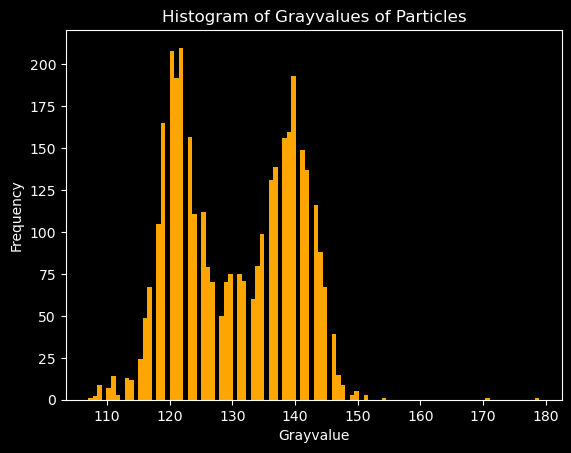

In [9]:
gray_hist, gray_hist_bins, _ = plt.hist(
    grayvalue,
    bins=100,
    alpha=1.0,
    label="Grayvalue",
    cumulative=False,
    density=False,
    color="orange",
)
plt.title("Histogram of Grayvalues of Particles")
plt.xlabel("Grayvalue")
plt.ylabel("Frequency")
# plt.legend()
plt.show()

gray_hist_bins = (gray_hist_bins[:-1] + gray_hist_bins[1:]) / 2

In [10]:
data = cfg_data.AnalysisBase(Path("../config.toml"))
vol_hist = data.histogram()
grayscale_landmarks = data.grayscale_landmarks()

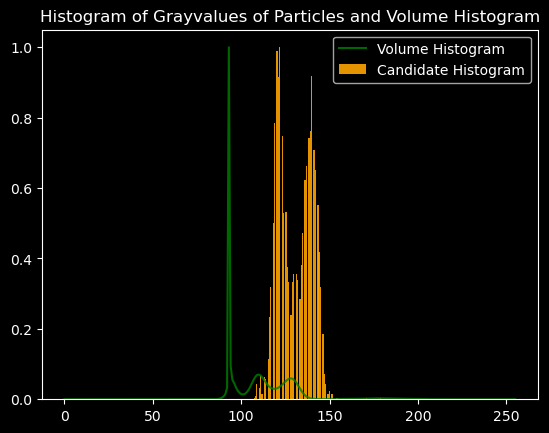

In [11]:
plt.bar(gray_hist_bins, gray_hist/gray_hist.max(), color="orange", alpha=0.9, label="Candidate Histogram")
plt.plot(vol_hist/vol_hist.max(), color="green", alpha=0.8, label="Volume Histogram")
plt.title("Histogram of Grayvalues of Particles and Volume Histogram")
plt.legend()

In [12]:
results = gaussian_mixture_fit(grayvalue, n_components=2)

In [23]:
gm_means = results['means']
gm_stds = np.sqrt(results['stds'])
gm_weights = results['weights']

print("Gaussian Mixture Model Results:")
print("Means:", gm_means)
print("Standard Deviations:", gm_stds)
print("Weights:", gm_weights)


Gaussian Mixture Model Results:
Means: [138.66507 121.83468]
Standard Deviations: [2.1221502 2.0393927]
Weights: [0.5076141  0.49238592]


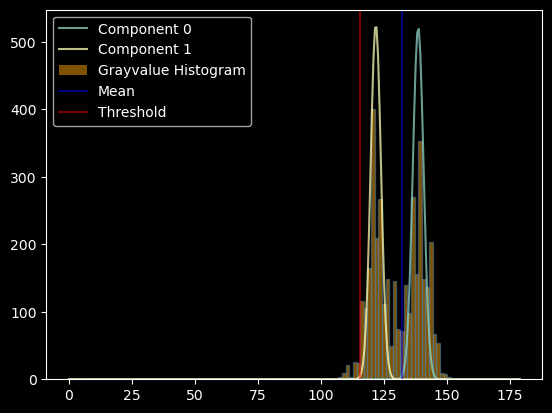

In [22]:
from scipy.stats import norm


#_ = plt.hist(grayvalue, grayvalue.max(), alpha = 0.9, density=True, label="Grayvalue Histogram", color="orange")
plt.hist(grayvalue, bins=50, alpha=0.5, color='orange', edgecolor='steelblue')


scale = gray_hist_bins[1] - gray_hist_bins[0]
scale *= len(grayvalue) + 4000

x = np.linspace(0, grayvalue.max(), 300)
for i in range(2):
    mean = gm_means[i]
    std = gm_stds[i]
    weight = gm_weights[i]
    plt.plot(x, scale *weight * norm.pdf(x, mean, std), label=f'Component {i}', alpha=0.75)

_ = plt.hist(grayvalue, grayvalue.max(), alpha = 0.5, density=True, label="Grayvalue Histogram", color="orange")
plt.axvline(x=gm_means[0] - 3*gm_stds[0], color="blue", alpha=0.5, label="Mean")
plt.axvline(x=gm_means[1] - 3*gm_stds[1], color="red", alpha=0.5, label="Threshold")
plt.legend()
plt.show()

In [ ]:
vol_hist[:grayscale_landmarks["air_grayvalue"] + 1] = 0
vol_hist_plot = vol_hist / np.max(vol_hist)
plt.plot(vol_hist_plot, color="orange", alpha=0.75)

labels = np.arange(0, 255, 255/100)
len(labels), len(gray_hist[0])
plt.bar(labels, gray_hist[0], alpha = 0.5)

In [ ]:
labels = np.arange(0, 255, 255/100)
len(labels), len(gray_hist[0])
plt.bar(labels, gray_hist[0])